<a href="https://colab.research.google.com/github/Shreyasingh911/Space-Invaders-using-python-and-pygame/blob/main/courses/udacity_intro_to_tensorflow_for_deep_learning/l01c01_introduction_to_colab_and_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [8]:
# -----------------------------
#  PREPROCESSING
# -----------------------------

df = pd.read_csv('breastcancer.csv')

# Drop ID column
df = df.drop(columns=['id'])

# Convert diagnosis (M/B) → (1/0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Features & labels for classification
X = df.drop('diagnosis', axis=1)
y_clf = df['diagnosis']

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Classification train-test split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled_df, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

# Regression target
y_reg = df['area_worst']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_df, y_reg, test_size=0.3, random_state=42
)

print("--- Model Implementation and Evaluation ---")
print("Dataset loaded, scaled, and split successfully.\n")

--- Model Implementation and Evaluation ---
Dataset loaded, scaled, and split successfully.



In [9]:
# -----------------------------
# 1. NAIVE BAYES (Classification)
# -----------------------------
print("1. Naïve Bayes Classifier:")
nb_model = GaussianNB()
nb_model.fit(X_train_clf, y_train_clf)
y_pred_nb = nb_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_nb):.4f}\n")

1. Naïve Bayes Classifier:
  Accuracy: 0.9357



In [10]:
# 2. SIMPLE LINEAR REGRESSION
# -----------------------------
X_simple_reg = X_scaled_df[['radius_mean']]
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_simple_reg, df['area_mean'], test_size=0.3, random_state=42
)

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)
y_pred_slr = slr_model.predict(X_test_slr)

print("2. Simple Linear Regression (radius_mean -> area_mean):")
print(f"  MSE: {mean_squared_error(y_test_slr, y_pred_slr):.4f}")
print(f"  R^2 Score: {r2_score(y_test_slr, y_pred_slr):.4f}\n")

2. Simple Linear Regression (radius_mean -> area_mean):
  MSE: 2421.2025
  R^2 Score: 0.9784



In [11]:
# -----------------------------
# 3. MULTIPLE LINEAR REGRESSION
# -----------------------------
mlr_model = LinearRegression()
mlr_model.fit(X_train_reg, y_train_reg)
y_pred_mlr = mlr_model.predict(X_test_reg)

print("3. Multiple Linear Regression (All Features -> area_worst):")
print(f"  MSE: {mean_squared_error(y_test_reg, y_pred_mlr):.4f}")
print(f"  R^2 Score: {r2_score(y_test_reg, y_pred_mlr):.4f}\n")

3. Multiple Linear Regression (All Features -> area_worst):
  MSE: 0.0000
  R^2 Score: 1.0000



In [12]:
# -----------------------------
# 4. POLYNOMIAL REGRESSION
# -----------------------------
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_slr)
X_test_poly = poly.transform(X_test_slr)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_slr)
y_pred_poly = poly_model.predict(X_test_poly)

print("4. Polynomial Regression (2-degree radius_mean -> area_mean):")
print(f"  MSE: {mean_squared_error(y_test_slr, y_pred_poly):.4f}")
print(f"  R^2 Score: {r2_score(y_test_slr, y_pred_poly):.4f}\n")

4. Polynomial Regression (2-degree radius_mean -> area_mean):
  MSE: 248.0987
  R^2 Score: 0.9978



In [13]:
# -----------------------------
# 5. RIDGE & LASSO REGRESSION
# -----------------------------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_model.predict(X_test_reg)

print("5. Ridge Regression:")
print(f"  MSE: {mean_squared_error(y_test_reg, y_pred_ridge):.4f}")
print(f"  R^2 Score: {r2_score(y_test_reg, y_pred_ridge):.4f}")

lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso_model.predict(X_test_reg)

print("\n  Lasso Regression:")
print(f"  MSE: {mean_squared_error(y_test_reg, y_pred_lasso):.4f}")
print(f"  R^2 Score: {r2_score(y_test_reg, y_pred_lasso):.4f}\n")

5. Ridge Regression:
  MSE: 95.0051
  R^2 Score: 0.9997

  Lasso Regression:
  MSE: 0.9545
  R^2 Score: 1.0000



In [14]:
# -----------------------------
# 6. LOGISTIC REGRESSION
# -----------------------------
print("6. Logistic Regression:")
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_clf, y_train_clf)
y_pred_logreg = logreg_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_logreg):.4f}\n")

6. Logistic Regression:
  Accuracy: 0.9708



In [15]:
# -----------------------------
# 7. ARTIFICIAL NEURAL NETWORK
# -----------------------------
print("7. Artificial Neural Network (MLPClassifier):")
ann_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
ann_model.fit(X_train_clf, y_train_clf)
y_pred_ann = ann_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_ann):.4f}\n")

7. Artificial Neural Network (MLPClassifier):
  Accuracy: 0.9708



In [16]:
# -----------------------------
# 8. KNN CLASSIFIER
# -----------------------------
print("8. K-NN Classifier (K=5):")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_clf, y_train_clf)
y_pred_knn = knn_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_knn):.4f}\n")


8. K-NN Classifier (K=5):
  Accuracy: 0.9649



In [17]:
# -----------------------------
# 9. DECISION TREE
# -----------------------------
print("9. Decision Tree Classification:")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_clf, y_train_clf)
y_pred_dt = dt_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_dt):.4f}\n")

9. Decision Tree Classification:
  Accuracy: 0.9006



In [18]:
# 10. SVM CLASSIFIER
# -----------------------------
print("10. SVM Classification (RBF Kernel):")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_clf, y_train_clf)
y_pred_svm = svm_model.predict(X_test_clf)
print(f"  Accuracy: {accuracy_score(y_test_clf, y_pred_svm):.4f}\n")

10. SVM Classification (RBF Kernel):
  Accuracy: 0.9649



11. K-Means Clustering (Finding 2 clusters):


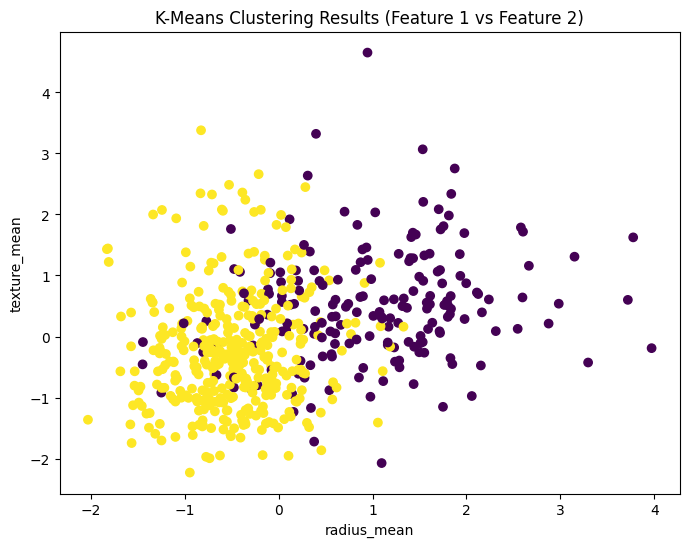

In [19]:
# -----------------------------
# 11. K-MEANS CLUSTERING
# -----------------------------
print("11. K-Means Clustering (Finding 2 clusters):")
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters_kmeans = kmeans.fit_predict(X_scaled_df)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled_df.iloc[:, 0], X_scaled_df.iloc[:, 1],
            c=clusters_kmeans, cmap='viridis', marker='o')
plt.title('K-Means Clustering Results (Feature 1 vs Feature 2)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.show()


12. Hierarchical Clustering (Showing Dendrogram):


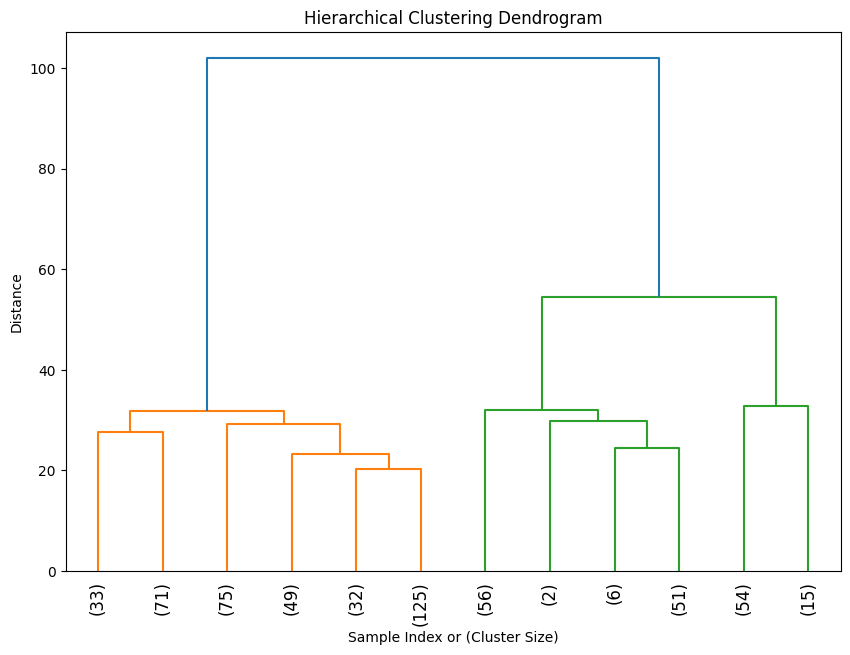

  First 10 Hierarchical Cluster labels: [0 0 0 0 0 0 0 0 0 0]



In [20]:
#12. Hierarchical Clustering (Unsupervised)
print("\n12. Hierarchical Clustering (Showing Dendrogram):")

# Using 'ward' linkage on the scaled data
linked = linkage(X_scaled, 'ward')

plt.figure(figsize=(10, 7))
dendrogram(
    linked,
    orientation='top',
    truncate_mode='lastp',
    p=12,
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Distance")
plt.show()

# Agglomerative Clustering (n_clusters = 2)
agglo = AgglomerativeClustering(n_clusters=2)
clusters_agglo = agglo.fit_predict(X_scaled_df)

print(f"  First 10 Hierarchical Cluster labels: {clusters_agglo[:10]}\n")
